In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/creditcardfraud/creditcard.csv


In [2]:
# =========================================================
# INSTALL NECESSARY LIBRARIES (Run these first!)
# =========================================================
!pip install --upgrade scikit-learn
!pip install imbalanced-learn
!pip install hmmlearn

# =========================================================
# STEP 1: Import Libraries
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub 

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.utils import resample # For the manual oversampling method
from hmmlearn import hmm # For the HMM
from IPython.display import display

# =========================================================
# STEP 2: Read and Inspect Data using kagglehub
# =========================================================
dataset_dir = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
csv_filename = 'creditcard.csv' 
full_file_path = os.path.join(dataset_dir, csv_filename)

try:
    df = pd.read_csv(full_file_path)
    print("Data loaded successfully.")
except FileNotFoundError:
    print(f"Error: Could not find '{csv_filename}'. Check the file name.")
    exit()

# Initial cleaning: Drop 'Time' column as per the pipeline
df.drop('Time', axis=1, inplace=True)

# Separate features and target from the original, unscaled DataFrame for HMM training
X_original = df.drop('Class', axis=1).copy() 
y_original = df['Class'].copy()

print("\nInitial Class Distribution:")
print(y_original.value_counts(normalize=True).round(4))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 56.2 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.8.0 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.8.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 90.4 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.8.0
    Uninstalling scikit-learn-1.8.0:
      Successfully uninstalled scikit-learn-1.8.0
ERR

In [3]:
# =========================================================
# STEP 3: Feature Scaling (Required before HMM)
# =========================================================
scaler = StandardScaler()
X_original_scaled_array = scaler.fit_transform(X_original)
X_original_scaled = pd.DataFrame(X_original_scaled_array, columns=X_original.columns)

# =========================================================
# STEP 4: HMM Feature Generation (Stochastic Model)
# =========================================================
# =========================================================
# CORRECTED STEP 4: HMM Feature Generation (Stochastic Model)
# =========================================================
print("\n--- HMM Feature Engineering (Corrected) ---")

# 1. Select ONLY normal transactions for HMM training
# (X_original_scaled is already defined and holds all scaled data)
y_original = df['Class'].copy() 
X_normal = X_original_scaled[y_original == 0] 

# 2. Train the HMM (GaussianHMM on Normal behavior)
n_components = 4 
model = hmm.GaussianHMM(n_components=n_components, covariance_type="diag", n_iter=100, random_state=42)
model.fit(X_normal) 
print(f"HMM trained successfully with {n_components} states on Normal transactions.")

# 3. Calculate the HMM Log-Likelihood (Anomaly Score) PER SAMPLE
# We iterate through each row (sample) and calculate the score for that tiny sequence.
# This gives us a vector of scores matching the length of the DataFrame.
log_likelihoods_list = [model.score(X_original_scaled.iloc[[i]]) for i in range(len(X_original_scaled))]
log_likelihoods = np.array(log_likelihoods_list)

# 4. Create the final feature set including the HMM score
X_hybrid = X_original_scaled.copy()
# Assign the scores directly to the new column
X_hybrid['HMM_LogLikelihood'] = log_likelihoods 

print("HMM feature ('HMM_LogLikelihood') added to the dataset.")





--- HMM Feature Engineering (Corrected) ---
HMM trained successfully with 4 states on Normal transactions.
HMM feature ('HMM_LogLikelihood') added to the dataset.


In [4]:
# =========================================================
# STEP 5: Oversampling by Random Sampling with Replacement
# =========================================================
# Combine X_hybrid features and y_original target for oversampling
df_hybrid = X_hybrid.copy()
df_hybrid['Class'] = y_original

# Separate majority and minority classes
df_majority = df_hybrid[df_hybrid['Class']==0] 
df_minority = df_hybrid[df_hybrid['Class']==1]

# Set n_samples equal to the count of the majority class
n_samples_majority = len(df_majority)

# Oversample minority class
df_minority_oversampled = resample(df_minority,
                                   replace=True,
                                   n_samples=n_samples_majority,
                                   random_state=42)

# Combine majority and oversampled minority class
df_oversampled_hybrid = pd.concat([df_minority_oversampled, df_majority])

# Final Features and Target for Modeling
X_oversampled_hybrid = df_oversampled_hybrid.drop('Class', axis=1)
y_oversampled_hybrid = df_oversampled_hybrid['Class']

print("\n--- Oversampling Results ---")
print("Class Distribution in Oversampled Data:")
print(y_oversampled_hybrid.value_counts())
print(f"Final Hybrid Dataset Shape: {X_oversampled_hybrid.shape}")


# =========================================================
# STEP 6: Split Final Hybrid Data (Train/Test)
# =========================================================
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_oversampled_hybrid, y_oversampled_hybrid, 
    test_size=0.2, 
    random_state=42,
)

print(f"Final Training Features shape: {X_train_final.shape}")
print(f"Final Testing Features shape: {X_test_final.shape}")


--- Oversampling Results ---
Class Distribution in Oversampled Data:
Class
1    284315
0    284315
Name: count, dtype: int64
Final Hybrid Dataset Shape: (568630, 30)
Final Training Features shape: (454904, 30)
Final Testing Features shape: (113726, 30)



Cross-Validation F1 Scores (Hybrid Model): [0.9955 0.9963 0.9967 0.9956 0.9958]
Average F1 Score: 0.996
Hybrid Random Forest Model trained successfully.

Classification Report (Hybrid HMM-RF Model):
               precision    recall  f1-score   support

           0       0.99      1.00      0.99     56980
           1       1.00      0.99      0.99     56746

    accuracy                           0.99    113726
   macro avg       0.99      0.99      0.99    113726
weighted avg       0.99      0.99      0.99    113726



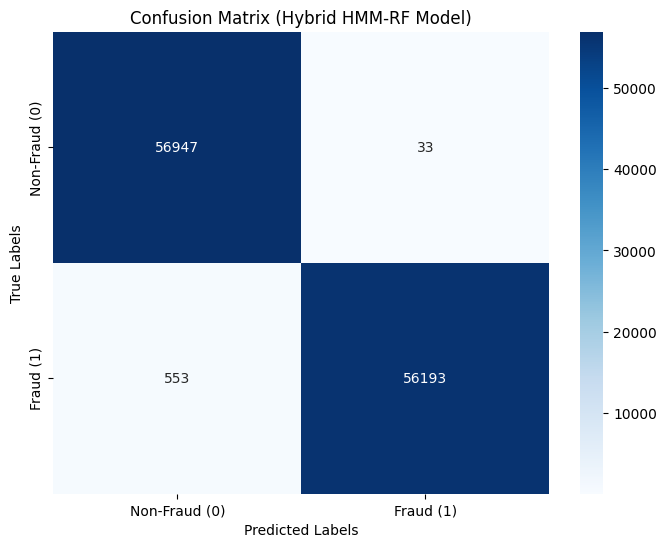

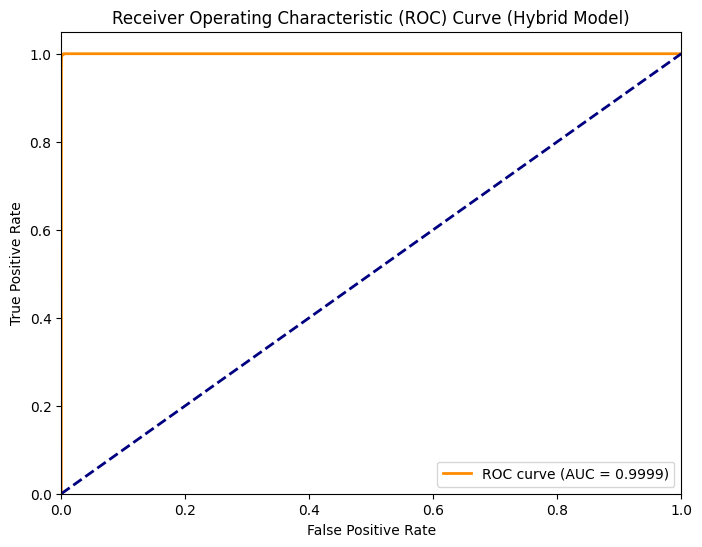

In [5]:
# =========================================================
# STEP 7: Initialize and Train Random Forest Model (Hybrid Classifier)
# =========================================================
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

# 5-fold Cross-Validation on F1 Score
cv_scores = cross_val_score(
    rf_model, 
    X_train_final, 
    y_train_final, 
    cv=5, 
    scoring='f1'
)

print(f"\nCross-Validation F1 Scores (Hybrid Model): {cv_scores.round(4)}")
print(f"Average F1 Score: {np.mean(cv_scores).round(4)}")

rf_model.fit(X_train_final, y_train_final)
print("Hybrid Random Forest Model trained successfully.")

# =========================================================
# STEP 8: Predictions and Classification Report
# =========================================================
y_pred = rf_model.predict(X_test_final)
print("\nClassification Report (Hybrid HMM-RF Model):\n", classification_report(y_test_final, y_pred))

# =========================================================
# STEP 9: Visualize Confusion Matrix
# =========================================================
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_final, y_pred)
sns.heatmap(
    cm,
    annot=True, 
    fmt='d',       
    cmap='Blues',
    xticklabels=['Non-Fraud (0)', 'Fraud (1)'],
    yticklabels=['Non-Fraud (0)', 'Fraud (1)']
)
plt.title('Confusion Matrix (Hybrid HMM-RF Model)')
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')
plt.show()

# =========================================================
# STEP 10: Analyze and Plot ROC Curve / AUC Score
# =========================================================
y_pred_proba = rf_model.predict_proba(X_test_final)[:, 1]
fpr, tpr, _ = roc_curve(y_test_final, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (Hybrid Model)')
plt.legend(loc="lower right")
plt.show()


Top Feature Importances (Including HMM Log-Likelihood):


,Feature,Importance
13,V14,0.209919
9,V10,0.115543
29,HMM_LogLikelihood,0.101054
3,V4,0.097193
16,V17,0.080267
11,V12,0.076053
10,V11,0.058563
2,V3,0.049677
15,V16,0.030552
1,V2,0.025137


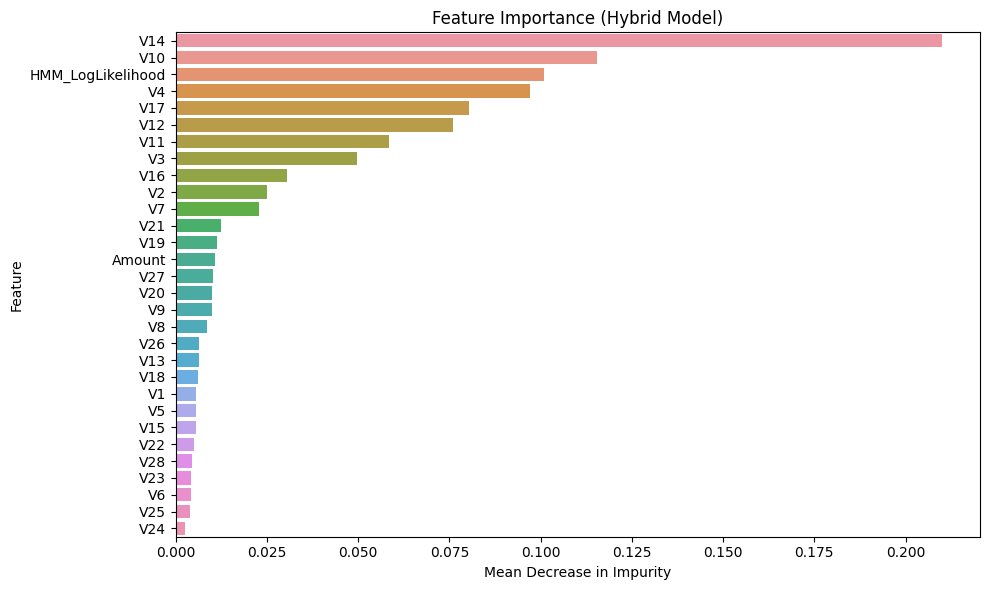

In [6]:
# =========================================================
# STEP 9: Analyze and Visualize Feature Importance (Hybrid Model)
# =========================================================

# The rf_model is trained on X_train_final (which contains the HMM feature)

# 1. Extract feature importances from the trained Random Forest model
importances = rf_model.feature_importances_

# 2. Create a DataFrame using the feature importances and the column names from the 
#    final hybrid feature set (X_oversampled_hybrid)
feature_imp = pd.DataFrame({
    'Feature': X_oversampled_hybrid.columns, # Use the correct columns from the hybrid set
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nTop Feature Importances (Including HMM Log-Likelihood):")
display(feature_imp.head(10)) # Display top 10 to ensure HMM feature is visible

# 3. Visualize the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp)
plt.title('Feature Importance (Hybrid Model)')
plt.xlabel('Mean Decrease in Impurity')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()